## Introduction

In this notebook, I analyze the Pittsburgh Parking Meters dataset to help answer the question: *What is the best neighborhood in Pittsburgh?

Instead of focusing on parking availability, I define “best neighborhood” based on parking affordability. In this analysis, a better neighborhood is one where parking is cheaper on average, making it more accessible and cost-friendly for drivers.

The dataset contains information about parking meter locations, status, zones, and hourly rates. Since the dataset does not explicitly define neighborhoods, I use the “zone” field as a proxy for neighborhood boundaries.

The goal of this analysis is to compute the average parking cost per zone and use it as the metric to identify the most affordable neighborhood in Pittsburgh.

## The Metric

To evaluate what makes a neighborhood “best,” I define my metric based on parking affordability.

In this analysis, a better neighborhood is one where parking is cheaper on average. Therefore, the metric I use is the average hourly parking rate within each zone.

The dataset provides hourly parking rates for individual meters, along with their status and zone information. Since neighborhoods are not explicitly labeled in the dataset, I use the “zone” field as a proxy for neighborhood boundaries.

To compute the metric, I first clean the hourly rate values by converting them from strings (e.g., "$1/hr") into numerical values. I then filter the dataset to include only active parking meters and group the data by zone. Finally, I calculate the average hourly rate for each zone, which allows me to compare parking affordability across different areas of Pittsburgh.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("parkingRates.csv")
df.head()

,_id,id,location,location_type,latitude,longitude,status,zone,all_groups,guid,in_service_utc,rate,max_hours,hours,restrictions,special_events,rate_as_of
0,1,410168-SCHEDR4402,SCHENLEY DR,On street,40.440574,-79.948103,Removed,410 - Oakland 4,CMU Study|410 - Oakland 4|Z - Inactive/Removed...,EE7C4FB7-038A-461A-A667-002870BA4155,2012-08-27T11:24:43,NaN,NaN,NaN,NaN,NaN,2019-01-29
1,2,421009-CEDAR-0302,CEDAR AVE,On street,40.451356,-80.001150,Active,421 - NorthSide,NORTHSIDE|421 - NorthSide,5BAC585B-FE5C-4090-ABF8-005D6C670EF1,2013-08-08T11:34:15,$1/hr,4 HRS,"M-Sat, 8a-6p","M-F, 7AM-9AM",NaN,2019-01-29
2,3,409242-NDTHRG0106,N DITHRIDGE ST,On street,40.448784,-79.951793,Active,409 - Oakland 3,409 - Oakland 3|OAKLAND3,F4BDCD95-6853-413F-A1C6-009AF3F9D725,2012-09-04T16:08:27,$3/hr,No Max,"M-Sat, 8a-6p",NaN,NaN,2019-01-29
3,4,PBP412,Virtual Terminal for ParkMobile,Virtual Zone,NaN,NaN,Active,412 - East Liberty,EASTLIB,8FAADCCE-A7BD-4988-85FC-00DCAB30782C,2015-10-23T16:56:58,NaN,NaN,NaN,NaN,NaN,2019-01-29
4,5,426002-CENTRE1802,CENTRE AVE,On street,40.442621,-79.982096,Active,426 - Hill District,Hill District|426 - Hill District|HILL-DIST,DFCD9083-EE1C-477D-8F82-00F688A1F78C,2017-07-17T11:24:27,$1/hr,2 HRS,"M-Sat, 8a-6p",NaN,NaN,2019-01-29


In [5]:



df_active = df[df["status"] == "Active"].copy()


df_active["rate_clean"] = df_active["rate"].str.replace("$", "", regex=False)
df_active["rate_clean"] = df_active["rate_clean"].str.replace("/hr", "", regex=False)
df_active["rate_clean"] = pd.to_numeric(df_active["rate_clean"], errors="coerce")

df_active["rate_clean"] = df_active["rate_clean"].fillna(0)

df_active["neighborhood"] = df_active["zone"].str.replace(
    r"^\d+\s*-\s*|\s*\d+$", "", regex=True
)
avg_cost_by_neighborhood = df_active.groupby("neighborhood")["rate_clean"].mean()

avg_cost_sorted = avg_cost_by_neighborhood.sort_values()

avg_cost_sorted


neighborhood
Technology Drive             0.000000
Centre Craig                 0.000000
Allentown                    0.375000
Carrick                      0.450000
Brookline Lot                0.500000
Oberservatory Hill Lot       0.500000
Beechview Lot                0.500000
Walter/Warrington Lot        0.500000
Homewood Zenith Lot          0.500000
Asteroid Warrington Lot      0.500000
Ansley Beatty Lot            0.500000
52nd & Butler Lot            0.500000
42nd & Butler Lot            0.500000
Taylor Street Lot            0.500000
19th & Carson Lot            0.500000
Main/Alexander Lot           0.500000
JCC/Forbes Lot               0.666667
18th & Carson Lot            0.666667
Sheridan Harvard Lot         0.666667
Shiloh Street Lot            0.666667
Tamello Beatty Lot           0.666667
Penn Circle NW Lot           0.666667
Eva Beatty Lot               0.666667
Friendship Cedarville Lot    0.666667
East Carson Lot              0.666667
East Ohio Street Lot         0.666667

After deleting those are not communities

Allentown                    0.375000
Carrick                      0.450000
Beechview                    0.888889
Hill District                0.800000
Knoxville                    0.857143
West End                     0.857143
Mt. Washington               0.944444
Brookline                    0.954545
Lawrenceville                0.965517
Bloomfield (On-street)       0.985507
NorthSide                    0.989130
Shadyside                    1.138889
Uptown                       1.438356
Squirrel Hill                1.447368
East Liberty                 1.447368
Oakland                      2.564246
Downtown                     3.840000

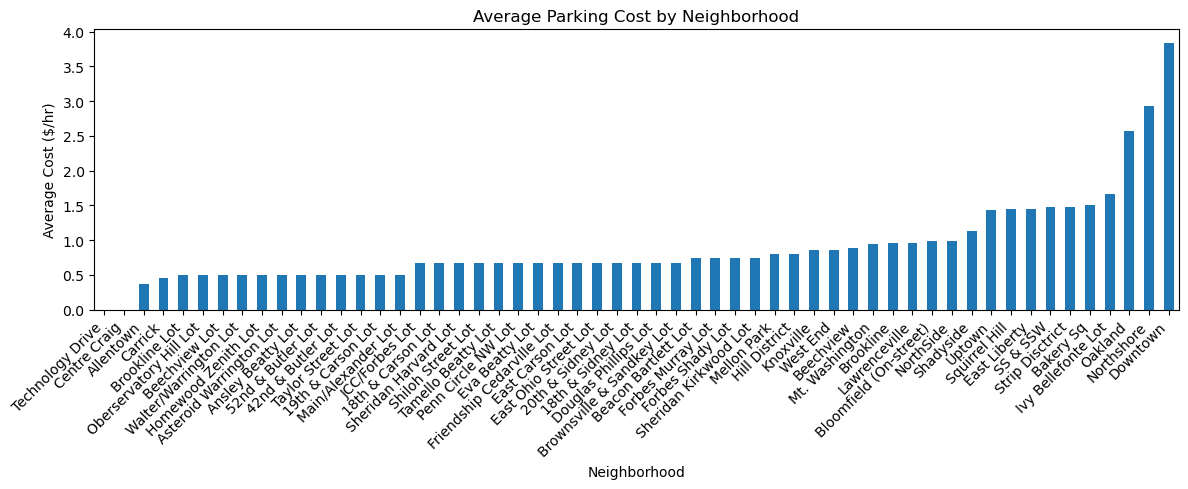

In [6]:
import matplotlib.pyplot as plt

avg_cost_sorted.plot(kind="bar", figsize=(12,5))

plt.title("Average Parking Cost by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Average Cost ($/hr)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [7]:
print("""
Based on the average parking cost metric, the best neighborhood is:
Allentown with an average cost of $0.38/hour.

This neighborhood is considered the 'best' because it has the lowest average parking cost among all Pittsburgh neighborhoods in the dataset.
""")


Based on the average parking cost metric, the best neighborhood is:
Allentown with an average cost of $0.38/hour.

This neighborhood is considered the 'best' because it has the lowest average parking cost among all Pittsburgh neighborhoods in the dataset.



In [8]:
print("""
Conclusion:

In this project, I defined the best neighborhood based on parking affordability. According to the data, Allentown has the lowest average parking cost, making it the most affordable neighborhood for parking.

However, this result may not fully reflect the overall quality of a neighborhood. Personally, I might prefer neighborhoods like Shadyside or Oakland because of their convenience, safety, and amenities, even though parking is more expensive there.

This shows that while data can provide useful insights, the definition of “best” depends on personal preferences and other factors beyond just cost.
""")


Conclusion:

In this project, I defined the best neighborhood based on parking affordability. According to the data, Allentown has the lowest average parking cost, making it the most affordable neighborhood for parking.

However, this result may not fully reflect the overall quality of a neighborhood. Personally, I might prefer neighborhoods like Shadyside or Oakland because of their convenience, safety, and amenities, even though parking is more expensive there.

This shows that while data can provide useful insights, the definition of “best” depends on personal preferences and other factors beyond just cost.

